# Verification Notebook 2
## Event Chain Handling

## Overview

In this test case, we create a hybrid system where **a first event triggers a second event at the same real time instant**.
This is called an **event chain**.

We introduce the concept of **Dense Time**, where multiple events can occur at the same real time but are ordered sequentially.
Dense Time can be represented as pairs $(t, d)$ where $t$ is the real time and $d$ is the micro-step index.
The first event will be handled at dense time $(t_\text{e}, 0)$ and the second event at dense time $(t_\text{e}, 1)$.
The event chain can be seen in the system graph below.

In [1]:
import numpy as np

from syssimx.core.base import CoSimComponent
from syssimx.core.events import Event
from syssimx.core.port import PortSpec, PortType
from syssimx.system.connection import EventConnection
from syssimx.system.system import System
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

In [2]:
from plot_setup import set_professional_style, FULL_WIDTH, HALF_WIDTH, SUBFIG_048
plt = set_professional_style(latex=True, fontsize=10, savefig_format="pdf")

import logging

logging.basicConfig(
    level=logging.WARNING,  # keep third-party loggers quiet
    format="[%(module)s] %(levelname)s: %(message)s",
)
# Enable debug output for the syssimx package
logging.getLogger("syssimx").setLevel(logging.DEBUG)

In [3]:
from pathlib import Path
from matplotlib.lines import Line2D

HYBRID_OUT = Path.cwd() / "figures"
HYBRID_OUT.mkdir(parents=True, exist_ok=True)

HYBRID_COLORS = {
    "source_1": "tab:orange",
    "source_2": "tab:green",
    "combi": "tab:green",
    "listener": "tab:blue",
    "indicator": "tab:orange",
    "event": "0.25",
    "macro": "tab:purple",
    "zero": "0.35",
}

HYBRID_LINE_KW = dict(linewidth=1.8, marker="o", markersize=4)
HYBRID_EVENT_KW = dict(color=HYBRID_COLORS["event"], linestyle="--", linewidth=1.4, alpha=0.9, zorder=1)
HYBRID_MACRO_KW = dict(color=HYBRID_COLORS["macro"], linestyle=":", linewidth=1.0, alpha=0.9, zorder=0)
HYBRID_ZERO_KW = dict(color=HYBRID_COLORS["zero"], linestyle=":", linewidth=1.0, alpha=0.7)
HYBRID_LABEL_BOX = dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.0)


def nearest_value(time, values, t_ref):
    idx = np.argmin(np.abs(time - t_ref))
    return values[idx]


def time_window_mask(time, t_min, t_max):
    return (time >= t_min) & (time <= t_max)


def add_time_guides(axs, event_times, communication_times=()):
    axes = np.atleast_1d(axs)
    for ax in axes:
        for t_comm in communication_times:
            ax.axvline(t_comm, **HYBRID_MACRO_KW)
        for t_event in event_times:
            ax.axvline(t_event, **HYBRID_EVENT_KW)
        ax.grid(True, alpha=0.25)
        ax.ticklabel_format(axis="x", style="plain", useOffset=False)


def annotate_event(ax, label, xy, xytext, color):
    ax.annotate(
        label,
        xy=xy,
        xytext=xytext,
        arrowprops=dict(arrowstyle="->", color=color, lw=0.9, shrinkA=0, shrinkB=2),
        color=color,
        fontsize=8,
        bbox=HYBRID_LABEL_BOX,
    )


def save_hybrid_figure(fig, filename):
    fig.savefig(HYBRID_OUT / filename)


In [4]:
class HybridSource(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Event Source")
        self.x0 = x0
        self.v = v
        self.t0 = t0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(self, t: float | None = None, event_names: list[str] | None = []) -> None:
        self.outputs["x"].set(self.x, t=t)

    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot, t) -> None:
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()

class HybridCombi(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Combi")
        self.x0 = x0
        self.v_prev = v
        self.v_curr = v
        self.t0 = t0
        self.v_changed = False  # flag for velocity change
        self.input_specs.update(
            {"v_double": PortSpec(name="v_double", type=PortType.EVENT, direction="in")}
        )
        self.output_specs.update(
            {
                "x": PortSpec(name="x", type=PortType.REAL, direction="out"),
            }
        )

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v_curr * (t + dt - self.t0)

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ) -> None:
        self.outputs["x"].set(self.x, t=t)

    def snapshot_state(self):
        return {
            "t": self.t,
            "x": self.x,
            "v": self.v_curr,
            "v_prev": self.v_prev,
            "t0": self.t0,
        }

    def _handle_events_internal(self, event_names, t):
        if "v_double" in event_names:  # Fixed condition
            self.t0 = t
            self.x0 = self.x
            self.v_prev = self.v_curr
            self.v_curr = 2 * self.v_curr

    def restore_state(self, snapshot, t) -> None:
        self.t = t
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v_curr = snapshot["v"]
        self.v_prev = snapshot.get("v_prev", self.v_curr)

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()

class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)
    """

    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0
        self.v = v
        self.t0 = t0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})
        self.input_specs.update(
            {"v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in")}
        )

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ) -> None:
        self.outputs["x"].set(self.x, t=t)

    def _handle_events_internal(self, event_names, t):
        if "v_change" in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}


[system] INFO: Starting simulation run from t=0.0 to t=0.5 with dt=0.05
[hybrid] INFO: ================================================================================
[hybrid] INFO: Event crossing in [0.300000, 0.350000]: Source.v_double
[hybrid] DEBUG: Starting bisection for event localization ...
[hybrid] DEBUG: Indicators at left  (t=0.30000000): {'Source': {'v_double': -0.06666666666666665}, 'Combi': {'v_change': 1.0}}
[hybrid] DEBUG: Indicators at right (t=0.35000000): {'Source': {'v_double': 0.033333333333333326}, 'Combi': {'v_change': 1.0}}
[hybrid] DEBUG: Bisection iteration 1: interval [0.30000000, 0.35000000]
[hybrid] DEBUG: Bisection iteration 2: interval [0.32500000, 0.35000000]
[hybrid] DEBUG: Bisection iteration 3: interval [0.32500000, 0.33750000]
[hybrid] DEBUG: Bisection iteration 4: interval [0.33125000, 0.33750000]
[hybrid] DEBUG: Bisection iteration 5: interval [0.33125000, 0.33437500]
[hybrid] DEBUG: Bisection iteration 6: interval [0.33281250, 0.33437500]
[hybrid

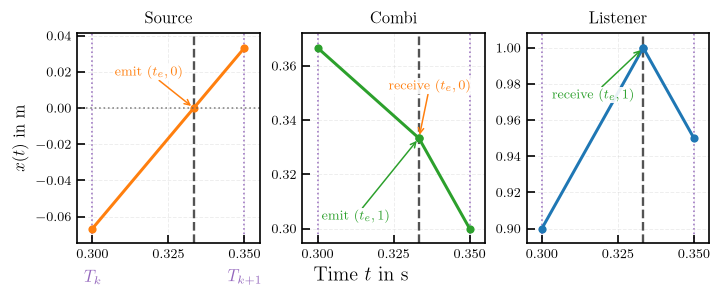

In [5]:
src_comp = HybridSource(name="Source", x0=-2/3, v=2)
combi_comp = HybridCombi(name="Combi", x0=2/3, v=-1)
listener_comp = HybridListener(name="Listener", x0=0.0, v=3.0)

components = [src_comp, combi_comp, listener_comp]

def event_indicator_zero_crossing(comp: HybridSource) -> float:
    return comp.x

def event_indicator_v_change(comp: HybridCombi) -> float:
    return -1.0 if comp.v_curr != comp.v_prev else 1.0

src_comp.add_event_indicator(
    name="v_double", func=event_indicator_zero_crossing, direction=1
)
combi_comp.add_event_indicator(
    name="v_change", func=event_indicator_v_change, direction=-1
)

event_connection_1 = EventConnection(
    src_comp=src_comp.name,
    src_port="v_double",
    dst_comp=combi_comp.name,
    dst_port="v_double",
)

event_connection_2 = EventConnection(
    src_comp=combi_comp.name,
    src_port="v_change",
    dst_comp=listener_comp.name,
    dst_port="v_invert",
)

event_connections = [event_connection_1, event_connection_2]

system = System(name="Hybrid Event Chain System")

for comp in components:
    system.add_component(comp)

for ev_conn in event_connections:
    system.add_event_connection(ev_conn)

system.initialize(t0=0.0)
system.algorithm.verbose = True
system.algorithm.record_internal_steps = True

system.run(t0=0.0, tf=0.5, dt=0.05)

time_src, data_src = src_comp.get_history_arrays()
x_src = data_src["x"]

time_combi, data_combi = combi_comp.get_history_arrays()
x_combi = data_combi["x"]

time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener["x"]

event_history = system.history.get_all_event_histories()
trigger_times_1 = event_history.get((src_comp.name, "v_double"), [])
trigger_times_2 = event_history.get((combi_comp.name, "v_change"), [])

trigger_time_1 = trigger_times_1[0].t
trigger_time_2 = trigger_times_2[0].t

fig, axs = plt.subplots(
    1,
    3,
    figsize=(FULL_WIDTH, 0.40 * FULL_WIDTH),
    sharex=True,
    constrained_layout=True,
)

# Both events must share the same physical time.
t_event = trigger_time_1
assert np.isclose(trigger_time_1, trigger_time_2, atol=1e-8)

communication_times = [0.30, 0.35]
t_min = communication_times[0] - 0.005
t_max = communication_times[1] + 0.005

add_time_guides(axs, event_times=[t_event], communication_times=communication_times)
for ax in axs:
    ax.set_xlim(t_min, t_max)
    ax.set_xticks([0.30, 0.325, 0.35])
    ax.margins(y=0.08)

axs[0].text(
    communication_times[0],
    -0.2,
    r"$T_k$",
    transform=axs[0].get_xaxis_transform(),
    ha="center",
    va="bottom",
    color=HYBRID_COLORS['macro'],
    fontsize=10,
)
axs[0].text(
    communication_times[1],
    -0.2,
    r"$T_{k+1}$",
    transform=axs[0].get_xaxis_transform(),
    ha="center",
    va="bottom",
    color=HYBRID_COLORS['macro'],
    fontsize=10,
)

mask_src = time_window_mask(time_src, t_min, t_max)
y_src_e = nearest_value(time_src, x_src, t_event)
axs[0].plot(time_src[mask_src], x_src[mask_src], color=HYBRID_COLORS["source_1"], **HYBRID_LINE_KW)
axs[0].axhline(0, **HYBRID_ZERO_KW)
axs[0].set_title("Source")
axs[0].set_ylabel(r"$x(t)$ in m")
annotate_event(
    axs[0],
    r"emit $(t_e,0)$",
    xy=(t_event, y_src_e),
    xytext=(t_event - 0.026, y_src_e + 0.018),
    color=HYBRID_COLORS["source_1"],
)

mask_combi = time_window_mask(time_combi, t_min, t_max)
y_combi_e = nearest_value(time_combi, x_combi, t_event)
axs[1].plot(time_combi[mask_combi], x_combi[mask_combi], color=HYBRID_COLORS["combi"], **HYBRID_LINE_KW)
axs[1].set_title("Combi")
annotate_event(
    axs[1],
    r"receive $(t_e,0)$",
    xy=(t_event, y_combi_e),
    xytext=(t_event - 0.01, y_combi_e + 0.018),
    color=HYBRID_COLORS["source_1"],
)
annotate_event(
    axs[1],
    r"emit $(t_e,1)$",
    xy=(t_event, y_combi_e),
    xytext=(t_event - 0.032, y_combi_e - 0.030),
    color=HYBRID_COLORS["combi"],
)

mask_listener = time_window_mask(time_listener, t_min, t_max)
y_listener_e = nearest_value(time_listener, x_listener, t_event)
axs[2].plot(time_listener[mask_listener], x_listener[mask_listener], color=HYBRID_COLORS["listener"], **HYBRID_LINE_KW)
axs[2].set_title("Listener")
annotate_event(
    axs[2],
    r"receive $(t_e,1)$",
    xy=(t_event, y_listener_e),
    xytext=(t_event - 0.030, y_listener_e - 0.028),
    color=HYBRID_COLORS["combi"],
)

fig.supxlabel(r"Time $t$ in s", x=0.5, y=0.02)
save_hybrid_figure(fig, "02_a_hybrid_event_chain.pdf")
plt.show()


# Strong Event Simultaneity

In [6]:
class HybridSource(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Event Source")
        self.x0 = x0
        self.v = v
        self.t0 = t0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(self, t: float | None = None) -> None:
        self.outputs["x"].set(self.x, t=t)

    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot, t) -> None:
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()

class HybridSource(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Event Source")
        self.x0 = x0
        self.v = v
        self.t0 = t0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(self, t: float | None = None) -> None:
        self.outputs["x"].set(self.x, t=t)

    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot, t) -> None:
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()

class HybridListener(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0,v: float = 1.0, t0: float = 0.0,
                 use_event_annotations: bool = False):
        super().__init__(name, group="Listener")
        self.x0 = x0
        self.v = v
        self.t0 = t0

        if use_event_annotations:
            self.event_annotations.update({
                    "v_invert": {"modifies": {"v"}},
                    "v_double": {"modifies": {"v"}},}
            )

            self.event_commutativity.update({("v_invert", "v_double"): True })

        self.input_specs.update({
                "v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in"),
                "v_double": PortSpec(name="v_double", type=PortType.EVENT, direction="in")})
        
        self.output_specs.update({
                "x": PortSpec(name="x", type=PortType.REAL, direction="out"),
                "v": PortSpec(name="v", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(self, t: float | None = None, event_names: list | None = None) -> None:
        self.outputs["x"].set(self.x, t=t)
        self.outputs["v"].set(self.v, t=t)

    def get_state(self):
        return self.snapshot_state()

    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot, t):
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]

    def _handle_events_internal(self, event_names, t):
        v_invert_events = set(["Trigger_1", "Trigger_2", "v_invert"])
        v_double_events = set(["v_double"])

        if v_invert_events.intersection(event_names):
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"[{self.name}] handled event at t={t:.4f}: v inverted from {-self.v} to {self.v}")
        elif v_double_events.intersection(event_names):
            self.t0 = t
            self.x0 = self.x
            self.v = 2.0 * self.v
            print(f"[{self.name}] handled event at t={t:.4f}: v doubled from {self.v / 2.0} to {self.v}")

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}

[system] INFO: Starting simulation run from t=0.0 to t=1.0 with dt=0.05
[hybrid] INFO: ================================================================================
[hybrid] INFO: Event crossing in [0.650000, 0.700000]: Source_1.v_invert, Source_2.v_double
[hybrid] DEBUG: Starting bisection for event localization ...
[hybrid] DEBUG: Indicators at left  (t=0.65000000): {'Source_1': {'v_invert': 0.016666666666666607}, 'Source_2': {'v_double': -0.016666666666666607}}
[hybrid] DEBUG: Indicators at right (t=0.70000000): {'Source_1': {'v_invert': -0.03333333333333344}, 'Source_2': {'v_double': 0.03333333333333344}}
[hybrid] DEBUG: Bisection iteration 1: interval [0.65000000, 0.70000000]
[hybrid] DEBUG: Bisection iteration 2: interval [0.65000000, 0.67500000]
[hybrid] DEBUG: Bisection iteration 3: interval [0.66250000, 0.67500000]
[hybrid] DEBUG: Bisection iteration 4: interval [0.66250000, 0.66875000]
[hybrid] DEBUG: Bisection iteration 5: interval [0.66562500, 0.66875000]
[hybrid] DEBUG:

[Listener] handled event at t=0.6667: v inverted from 3.0 to -3.0
[Listener] handled event at t=0.6667: v doubled from -3.0 to -6.0
[Listener] handled event at t=0.6667: v doubled from 3.0 to 6.0
[Listener] handled event at t=0.6667: v inverted from 6.0 to -6.0
[Listener] handled event at t=0.6667: v inverted from 3.0 to -3.0
[Listener] handled event at t=0.6667: v doubled from -3.0 to -6.0


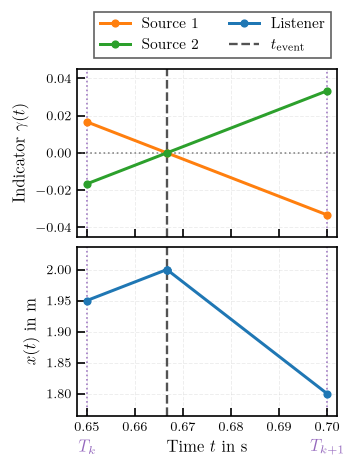

In [7]:
src_comp_1 = HybridSource(name="Source_1", x0=2 / 3, v=-1)
src_comp_2 = HybridSource(name="Source_2", x0=-2 / 3, v=1)
listener_comp = HybridListener(name="Listener", x0=0.0, v=3.0)

components = [src_comp_1, src_comp_2, listener_comp]

def event_indicator_zero_crossing(comp: HybridSource) -> float:
    return comp.x

src_comp_1.add_event_indicator(
    name="v_invert", func=event_indicator_zero_crossing, direction=-1
)
src_comp_2.add_event_indicator(
    name="v_double", func=event_indicator_zero_crossing, direction=1
)

connection_1 = EventConnection(
    src_comp=src_comp_1.name,
    src_port="v_invert",
    dst_comp=listener_comp.name,
    dst_port="v_invert"
)

connection_2 = EventConnection(
    src_comp=src_comp_2.name,
    src_port="v_double",
    dst_comp=listener_comp.name,
    dst_port="v_double"
)

event_connections = [connection_1, connection_2]

system = System(name="Hybrid System - Event Commutativity")

for comp in components:
    system.add_component(comp)

for ev_conn in event_connections:
    system.add_event_connection(ev_conn)

system.initialize(t0=0.0)
system.algorithm.verbose = True
system.algorithm.record_internal_steps = True

system.run(t0=0.0, tf=1.0, dt=0.05)

time_src_1, data_src_1 = src_comp_1.get_history_arrays()
x_src_1 = data_src_1["x"]

time_src_2, data_src_2 = src_comp_2.get_history_arrays()
x_src_2 = data_src_2["x"]

time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener["x"]

event_history = system.history.get_all_event_histories()
trigger_times_1 = event_history.get((src_comp_1.name, "v_invert"), [])
trigger_times_2 = event_history.get((src_comp_2.name, "v_double"), [])

trigger_time_1 = trigger_times_1[0].t
trigger_time_2 = trigger_times_2[0].t
assert np.isclose(trigger_time_1, trigger_time_2, atol=1e-8)

t_event = trigger_time_1
macro_dt = 0.05
t_left = np.floor((t_event + 1e-12) / macro_dt) * macro_dt
t_right = t_left + macro_dt
t_min = t_left - 0.002
t_max = t_right + 0.002

fig, (ax_src, ax_lis) = plt.subplots(
    2,
    1,
    figsize=(HALF_WIDTH, 0.56 * FULL_WIDTH),
    sharex=True,
    constrained_layout=True,
)

add_time_guides((ax_src, ax_lis), event_times=[t_event], communication_times=[t_left, t_right])

mask_src_1 = time_window_mask(time_src_1, t_min, t_max)
mask_src_2 = time_window_mask(time_src_2, t_min, t_max)
mask_listener = time_window_mask(time_listener, t_min, t_max)

ax_src.axhline(0, **HYBRID_ZERO_KW)
ax_src.plot(time_src_1[mask_src_1], x_src_1[mask_src_1], label="Source 1", color=HYBRID_COLORS["source_1"], **HYBRID_LINE_KW)
ax_src.plot(time_src_2[mask_src_2], x_src_2[mask_src_2], label="Source 2", color=HYBRID_COLORS["source_2"], **HYBRID_LINE_KW)
ax_src.set_ylabel(r"Indicator $\gamma(t)$")
ax_src.margins(y=0.18)

ax_lis.plot(time_listener[mask_listener], x_listener[mask_listener], label="Listener", color=HYBRID_COLORS["listener"], **HYBRID_LINE_KW)
ax_lis.set_ylabel(r"$x(t)$ in m")
ax_lis.set_xlabel(r"Time $t$ in s")
#ax_lis.legend(loc="upper center", ncol=1)
ax_lis.margins(y=0.18)

ax_lis.text(
    t_left,
    -0.23,
    r"$T_{k}$",
    transform=ax_lis.get_xaxis_transform(),
    ha="center",
    va="bottom",
    color=HYBRID_COLORS['macro'],
    fontsize=10,
)

ax_lis.text(
    t_right,
    -0.23,
    r"$T_{k+1}$",
    transform=ax_lis.get_xaxis_transform(),
    ha="center",
    va="bottom",
    color=HYBRID_COLORS['macro'],
    fontsize=10,
)

ax_lis.set_xlim(t_min, t_max)

legend_handles = [
    Line2D([0], [0], color=HYBRID_COLORS["source_1"], linestyle="-", marker="o", markersize=4, label=r"Source 1"),
    Line2D([0], [0], color=HYBRID_COLORS["source_2"], linestyle="-", marker="o", markersize=4, label=r"Source 2"),
    Line2D([0], [0], color=HYBRID_COLORS["listener"], linestyle="-", marker='o', markersize=4, label=r"Listener"),
    Line2D([0], [0], color=HYBRID_COLORS["event"], linestyle="--", linewidth=1.4, alpha=0.9, label=r"$t_\mathrm{event}$"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.6, 1.15))


save_hybrid_figure(fig, "02_b_strong_simultaneity.pdf")
plt.show()


# Internal Event Reporting

In [8]:
class EventReportingComponent(CoSimComponent):
    def __init__(self, name: str, T1: float, T2: float) -> None:
        super().__init__(name, group="Sources")
        
        self.dt_internal = 0.01
        self.h = 0.0
        self.h_prev = 0.0

        self.T1 = T1
        self.T2 = T2

        self.output_specs.update({"h": PortSpec(name="h", type=PortType.REAL, direction="out")})
    
    def _initialize_component(self, t0: float) -> None:
        self._initialize_ports_from_specs()
        self.h = (self.t - self.T1) * (self.t - self.T2)
        self.h_prev = self.h

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.internal_event_hints.clear()

        if dt < self.dt_internal - 1e-12:
            effective_dt = dt
        else:
            effective_dt = self.dt_internal

        t_current = t
        t_end = t + dt

        while t_current < t_end - 1e-12:
            step_size = min(effective_dt, t_end - t_current)

            self.h_prev = self.h
            t_prev = t_current

            t_current += step_size
            self.t = t_current
            self.h = (self.t - self.T1) * (self.t - self.T2)

            self._update_output_states(t=self.t)
            self._record_outputs(t=self.t)

            # Check for zero-crossing event
            if self.h_prev * self.h < 0:
                self.report_internal_event(
                    event_name="zero_crossing",
                    t_before=t_prev,  # self.t - self.dt_internal,
                    t_after=t_current,
                    indicator_before=self.h_prev,
                    indicator_after=self.h,
                )

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ) -> None:
        self.outputs["h"].set(self.h, t=t)

    def snapshot_state(self):
        return {"t": self.t, "h": self.h, "h_prev": self.h_prev}

    def restore_state(self, snapshot, t: float | None = None) -> None:
        self.t = snapshot["t"]
        self.h = snapshot["h"]
        self.h_prev = snapshot.get("h_prev", self.h)
        # Clear internal hints on restore - they're no longer valid
        self.internal_event_hints.clear()

    def reset(self) -> None:
        super().reset()
        self.h = 0.0
        self.h_prev = 0.0

class EventListenerComponent(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0
        self.v = v
        self.t0 = t0

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})
        self.input_specs.update(
            {"v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in")}
        )
        self._initialize_ports_from_specs()

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ) -> None:
        self.outputs["x"].set(self.x, t=t)

    def _handle_events_internal(self, event_names, t):
        if "zero_crossing" in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled event at t={t:.4f}: v inverted from {-self.v} to {self.v}")

    def reset(self) -> None:
        super().reset()
        self.x0 = 0.0
        self.v = 1.0
        self.t0 = 0.0

[system] INFO: Starting simulation run from t=0.0 to t=1.0 with dt=0.2
[hybrid] DEBUG: Internal hint: EventReporter.zero_crossing in [0.44000000, 0.45000000]
[hybrid] DEBUG: Internal hint: EventReporter.zero_crossing in [0.54000000, 0.55000000]
[hybrid] INFO: ================================================================================
[hybrid] INFO: Event crossing in [0.400000, 0.600000]: EventReporter.zero_crossing, EventReporter.zero_crossing
[hybrid] DEBUG:   Internal hints from EventReporter: ['zero_crossing', 'zero_crossing']
[hybrid] DEBUG: Starting bisection for event localization ...
[hybrid] DEBUG: Narrowed interval via hint: [0.400000, 0.600000] -> [0.440000, 0.450000]
[hybrid] DEBUG: Indicators at left  (t=0.44000000): {'EventReporter': {'zero_crossing': 0.0010999999999999946}}
[hybrid] DEBUG: Indicators at right (t=0.45000000): {'EventReporter': {'zero_crossing': -5.5511151231257815e-18}}
[hybrid] DEBUG: Bisection iteration 1: interval [0.44000000, 0.45000000]
[hybrid] 

EventListener handled event at t=0.4500: v inverted from 0.25 to -0.25
EventListener handled event at t=0.5500: v inverted from -0.25 to 0.25

Events for ('EventReporter', 'zero_crossing'):
 - Event at t=0.45000000000000007
 - Event at t=0.550000000463257


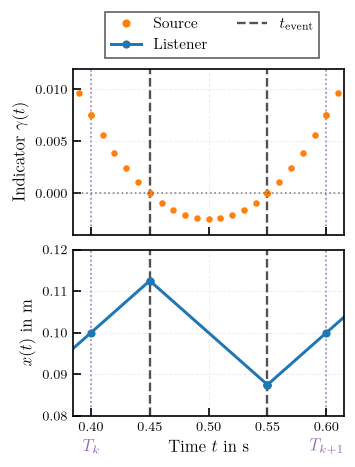

In [9]:
# 1) Create components
event_reporter = EventReportingComponent(name="EventReporter", T1=0.45, T2=0.55)
event_listener = EventListenerComponent(name="EventListener", x0=0.0, v=0.25)

# 2) Define event indicator functions
def event_indicator_function(comp: EventReportingComponent) -> float:
    return comp.h

# 3) Add event indicators to source components
event_reporter.add_event_indicator(
    name="zero_crossing", func=event_indicator_function, direction=0
)

# 7) Create system
system = System(name="Hybrid System - Internal Event Reporting")

# 8) Add components to system
system.add_component(event_reporter)
system.add_component(event_listener)

# 9) Create and add event connections to the system
connection = EventConnection(
    src_comp=event_reporter.name,
    src_port="zero_crossing",
    dst_comp=event_listener.name,
    dst_port="v_invert",
)
system.add_event_connection(connection)

# 10) Initialize and run the system
system.initialize(t0=0.0)

# 12) Run the simulation
system.run(t0=0.0, tf=1.0, dt=0.2)

time_reporter, history_reporter = event_reporter.get_history_arrays()
h_reporter = history_reporter["h"]

time_listener, history_listener = event_listener.get_history_arrays()
x_listener = history_listener["x"]

event_history = system.history.get_all_event_histories()
trigger_times = event_history.get((event_reporter.name, "zero_crossing"), [])
trigger_time_1 = trigger_times[0].t
trigger_time_2 = trigger_times[1].t

for event_key, events in event_history.items():
    print(f"\nEvents for {event_key}:")
    for event in events:
        print(f" - Event at t={event.t}")

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(HALF_WIDTH, 0.56 * FULL_WIDTH),
    sharex=True,
    constrained_layout=True,
)

communication_points = np.arange(0, 1.01, 0.2)
event_times = [trigger_time_1, trigger_time_2]
add_time_guides((ax_top, ax_bot), event_times=event_times, communication_times=communication_points)

ax_bot.text(
    0.4,
    -0.23,
    r"$T_k$",
    transform=ax_bot.get_xaxis_transform(),
    ha="center",
    va="bottom",
    color=HYBRID_COLORS['macro'],
    fontsize=10,
)
ax_bot.text(
    0.6,
    -0.23,
    r"$T_{k+1}$",
    transform=ax_bot.get_xaxis_transform(),
    ha="center",
    va="bottom",
    color=HYBRID_COLORS['macro'],
    fontsize=10,
)

ax_top.plot(
    time_reporter,
    h_reporter,
    color=HYBRID_COLORS["indicator"],
    linestyle="None",
    marker="o",
    markersize=3,
)
ax_top.axhline(0, **HYBRID_ZERO_KW)
ax_top.set_ylabel(r"Indicator $\gamma (t)$")
ax_top.set_ylim(-0.004, 0.012)

ax_bot.plot(time_listener, x_listener, color=HYBRID_COLORS["listener"], **HYBRID_LINE_KW)
ax_bot.set_xlabel(r"Time $t$ in s")
ax_bot.set_ylabel(r"$x(t)$ in m")
ax_bot.set_ylim(0.08, 0.12)

ax_top.set_xlim(0.385, 0.615)

legend_handles = [
    Line2D([0], [0], color=HYBRID_COLORS["indicator"], linestyle="None", marker="o", markersize=4, label=r"Source"),
    Line2D([0], [0], color=HYBRID_COLORS["listener"], linestyle="-", marker="o", markersize=4, label=r"Listener"),
    Line2D([0], [0], color=HYBRID_COLORS["event"], linestyle="--", linewidth=1.4, alpha=0.9, label=r"$t_\mathrm{event}$"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.6, 1.15))

save_hybrid_figure(fig, "02_c_internal_event_reporting.pdf")
plt.show()
